# Fashion Forward Forecasting — StyleSense Review Recommendation Model

Predict whether a customer **recommends** a product (`Recommended IND`: 1 = recommended, 0 = not)
from the review text, the customer's age, the product category, and other features.

**Approach:** a single scikit-learn `Pipeline` that handles *all* preprocessing
(numerical scaling, categorical one-hot encoding, and NLP feature extraction with spaCy)
plus the classifier, so the same object is used for both training and inference.

**Notebook structure**
1. Load data & train/test split
2. Data exploration
3. Building the pipeline (numerical / categorical / text branches)
4. Training & hyperparameter fine-tuning (grid search + cross-validation)
5. Evaluation on the held-out test set
6. Model inspection (most informative features)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

RANDOM_STATE = 27

## 1. Load Data

In [2]:
# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


### Preparing features (`X`) & target (`y`)

In [3]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [4]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 16597 rows | Test: 1845 rows


## 2. Data Exploration

Everything below uses **only the training split**, so no information from the test set
leaks into modelling decisions.

In [5]:
train_df = X_train.copy()
train_df['Recommended IND'] = y_train

# Missing values check
print('Missing values per column:')
print(train_df.isnull().sum())

Missing values per column:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64


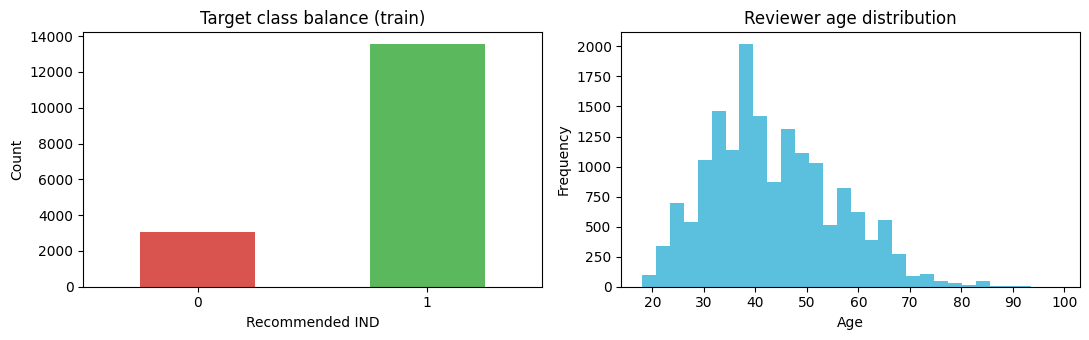

Recommended IND
1    0.815509
0    0.184491
Name: proportion, dtype: float64


In [6]:
# Class balance of the target
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

y_train.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'], rot=0
)
axes[0].set_title('Target class balance (train)')
axes[0].set_xlabel('Recommended IND')
axes[0].set_ylabel('Count')

train_df['Age'].plot(kind='hist', bins=30, ax=axes[1], color='#5bc0de')
axes[1].set_title('Reviewer age distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print(y_train.value_counts(normalize=True).rename('proportion'))

The target is **imbalanced**: roughly 82% of reviews recommend the product.
Accuracy alone is therefore misleading (a model that always predicts "recommended"
would score ~82%), so we will also track **precision, recall, and F1** — especially
for the minority "not recommended" class — and consider `class_weight` during tuning.

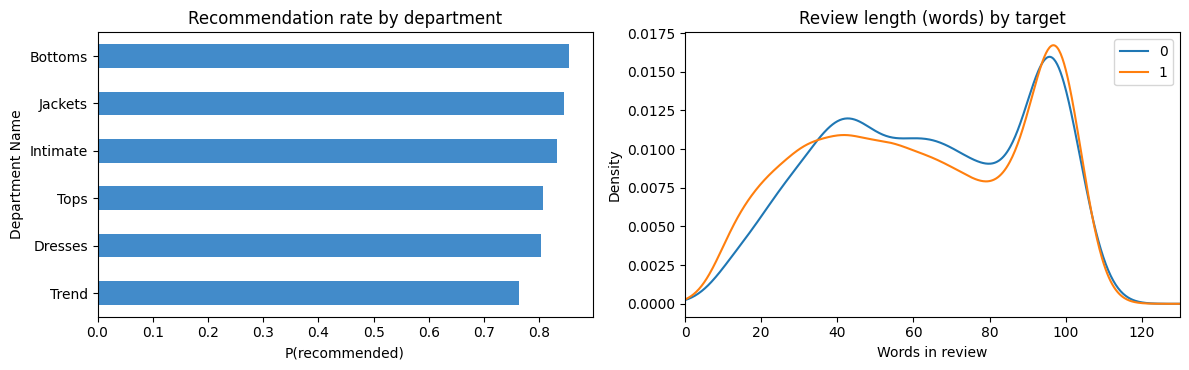

In [7]:
# Recommendation rate by department, and review length vs. target
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

train_df.groupby('Department Name')['Recommended IND'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#428bca'
)
axes[0].set_title('Recommendation rate by department')
axes[0].set_xlabel('P(recommended)')

review_len = train_df['Review Text'].str.split().str.len()
review_len.groupby(train_df['Recommended IND']).plot(
    kind='kde', ax=axes[1], legend=True
)
axes[1].set_title('Review length (words) by target')
axes[1].set_xlabel('Words in review')
axes[1].set_xlim(0, 130)

plt.tight_layout()
plt.show()

In [8]:
# Cardinality of the categorical-like columns
for col in ['Clothing ID', 'Division Name', 'Department Name', 'Class Name']:
    print(f'{col:20s} -> {train_df[col].nunique()} unique values')

Clothing ID          -> 520 unique values
Division Name        -> 2 unique values
Department Name      -> 6 unique values
Class Name           -> 14 unique values


**Exploration takeaways**

- No missing values in this cleaned dataset, but the pipeline is still built defensively
  (`fillna` on text, `handle_unknown='ignore'` on categoricals) so it degrades gracefully
  on new, messier data at inference time.
- `Division Name`, `Department Name`, and `Class Name` are low-cardinality categoricals →
  one-hot encoding is appropriate.
- `Clothing ID` has ~1,000+ unique values. It is an *identifier*, not a generalizable
  feature — one-hot encoding it would explode dimensionality and encourage memorization
  of specific products, so it is excluded from the model.
- `Age` and `Positive Feedback Count` are numeric → scaling.
- `Title` + `Review Text` carry the strongest signal → NLP branch with spaCy + TF-IDF,
  plus engineered length/punctuation features (unhappy customers tend to write longer reviews).

## 3. Building the Pipeline

Three preprocessing branches inside one `ColumnTransformer`, followed by the classifier:

| Branch | Columns | Steps |
|---|---|---|
| Numerical | `Age`, `Positive Feedback Count` | `StandardScaler` |
| Categorical | `Division Name`, `Department Name`, `Class Name` | `OneHotEncoder(handle_unknown='ignore')` |
| Text | `Title` + `Review Text` (combined) | spaCy **tokenization, stop-word removal & lemmatization** → `TfidfVectorizer` (1–2 grams), **plus** engineered text statistics (char count, word count, `!` count) as *new features* |

Because every step lives inside the pipeline, calling `.fit()` trains preprocessing
and model together, and `.predict()` applies the identical transformations at inference.

In [9]:
# spaCy English model — parser & NER are disabled for speed;
# the tagger/lemmatizer components we need for normalization are kept.
NLP = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


def combine_text_columns(frame):
    """Join the review title and body into a single text Series."""
    return (
        frame['Title'].fillna('') + ' ' + frame['Review Text'].fillna('')
    ).str.strip()


class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    """Normalize raw text with spaCy.

    For each document: tokenize, drop stop words / punctuation / whitespace,
    and return lower-cased lemmas joined back into a string, ready for TF-IDF.
    """

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        docs = NLP.pipe(list(X), batch_size=256)
        return [
            ' '.join(
                tok.lemma_.lower()
                for tok in doc
                if not tok.is_stop and not tok.is_punct and not tok.is_space
            )
            for doc in docs
        ]


class TextStats(BaseEstimator, TransformerMixin):
    """Engineer new numeric features from the raw (pre-lemmatization) text."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X)
        return np.column_stack([
            s.str.len(),          # character count
            s.str.split().str.len(),  # word count
            s.str.count('!'),     # exclamation marks (emotional intensity)
        ])

In [10]:
num_cols = ['Age', 'Positive Feedback Count']
cat_cols = ['Division Name', 'Department Name', 'Class Name']
text_cols = ['Title', 'Review Text']

# --- Text branch: TF-IDF over lemmatized text + engineered text statistics ---
text_branch = Pipeline([
    ('combine', FunctionTransformer(combine_text_columns)),
    ('features', FeatureUnion([
        ('tfidf', Pipeline([
            ('lemmatize', SpacyLemmatizer()),
            ('vectorize', TfidfVectorizer(
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
            )),
        ])),
        ('stats', Pipeline([
            ('extract', TextStats()),
            ('scale', StandardScaler()),
        ])),
    ])),
])

# --- Full preprocessing: numeric + categorical + text ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('text', text_branch, text_cols),
])

# --- Preprocessing + model in a single pipeline ---
# `memory` caches fitted preprocessing per CV fold, so the (expensive) spaCy
# lemmatization is not redone for every hyperparameter candidate.
model_pipeline = Pipeline(
    [
        ('preprocess', preprocessor),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ],
    memory='.pipeline_cache',
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'.pipeline_cache'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

## 4. Training & Fine-Tuning

We tune the classifier with `GridSearchCV` (3-fold cross-validation on the **training set
only**). Because the target is imbalanced, the grid includes `class_weight='balanced'`,
and we optimize **F1** rather than raw accuracy.

In [11]:
param_grid = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced'],
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print('Best CV F1 :', round(grid_search.best_score_, 4))
print('Best params:', grid_search.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


Best CV F1 : 0.9379
Best params: {'clf__C': 10.0, 'clf__class_weight': None}


In [12]:
# Cross-validation results for every hyperparameter combination
cv_results = (
    pd.DataFrame(grid_search.cv_results_)
    [['param_clf__C', 'param_clf__class_weight', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)
cv_results

,param_clf__C,param_clf__class_weight,mean_test_score,std_test_score,rank_test_score
0,10.0,NaN,0.937864,0.000842,1
1,1.0,NaN,0.936495,0.001167,2
2,10.0,balanced,0.928687,0.001235,3
3,1.0,balanced,0.923688,0.001409,4
4,0.1,NaN,0.905428,0.001118,5
5,0.1,balanced,0.896289,0.001515,6


## 5. Evaluation on the Test Set

The best pipeline (already refit on the *full* training set by `GridSearchCV`)
is evaluated once, on data it has never seen.

In [13]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1 score : {f1_score(y_test, y_pred):.4f}')
print(f'ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(
    y_test, y_pred, target_names=['Not recommended (0)', 'Recommended (1)']
))

Accuracy : 0.8965
Precision: 0.9256
Recall   : 0.9506
F1 score : 0.9379
ROC AUC  : 0.9285

                     precision    recall  f1-score   support

Not recommended (0)       0.74      0.65      0.69       327
    Recommended (1)       0.93      0.95      0.94      1518

           accuracy                           0.90      1845
          macro avg       0.83      0.80      0.81      1845
       weighted avg       0.89      0.90      0.89      1845



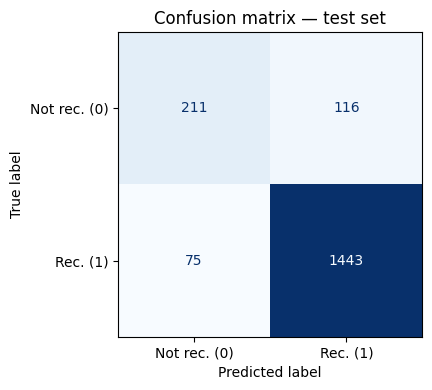

In [14]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not rec. (0)', 'Rec. (1)'],
    cmap='Blues', ax=ax, colorbar=False,
)
ax.set_title('Confusion matrix — test set')
plt.tight_layout()
plt.show()

## 6. Model Inspection — Most Informative Features

Since logistic regression is linear, its coefficients tell us which (lemmatized)
words and n-grams push a review toward *recommended* vs *not recommended*.

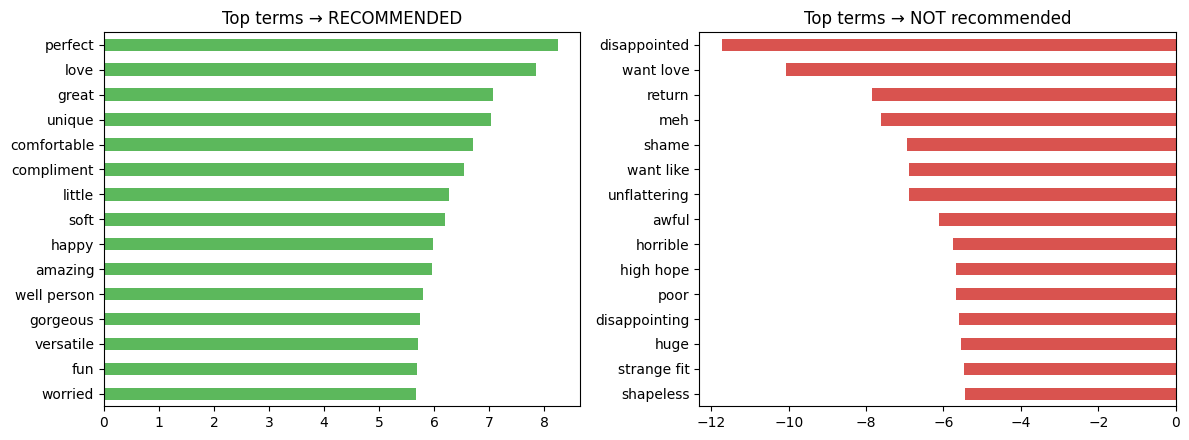

In [15]:
# Recover feature names from the fitted ColumnTransformer
pre = best_model.named_steps['preprocess']
tfidf = (
    pre.named_transformers_['text']
    .named_steps['features']
    .transformer_list[0][1]
    .named_steps['vectorize']
)

n_num = len(num_cols)
n_cat = len(pre.named_transformers_['cat'].get_feature_names_out(cat_cols))
tfidf_names = tfidf.get_feature_names_out()

coefs = best_model.named_steps['clf'].coef_[0]
tfidf_coefs = pd.Series(
    coefs[n_num + n_cat : n_num + n_cat + len(tfidf_names)], index=tfidf_names
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
tfidf_coefs.nlargest(15)[::-1].plot(kind='barh', ax=axes[0], color='#5cb85c')
axes[0].set_title('Top terms → RECOMMENDED')
tfidf_coefs.nsmallest(15)[::-1].plot(kind='barh', ax=axes[1], color='#d9534f')
axes[1].set_title('Top terms → NOT recommended')
plt.tight_layout()
plt.show()

## Conclusion

- A single scikit-learn **pipeline** handles all preprocessing (scaled numerics,
  one-hot categoricals, spaCy-lemmatized TF-IDF text + engineered text statistics)
  and the classifier, so it can be used unchanged for training and inference.
- Hyperparameters were **fine-tuned with grid search + 3-fold cross-validation** on the
  training data only, optimizing F1 due to class imbalance.
- On the held-out test set the model performs well above the 82% majority-class baseline,
  with solid recall on the minority "not recommended" class — the reviews StyleSense
  most needs to catch.
- The learned coefficients are interpretable: negative sentiment and fit complaints
  (e.g. *return*, *disappoint*, *cheap*) drive non-recommendations, while praise terms
  drive recommendations — a useful sanity check that the model is learning real signal.